---
date: "2026-07-13"
date-modified: last-modified
format:
  html:
    toc: true
---
<!-- CELL BREAK -->

# Measurable Sets (Lebesgue)

In measure theory, defining the "size" or measure of every possible subset of $\mathbb{R}$ consistently is impossible due to paradoxes like the Banach-Tarski paradox (or the construction of the Vitali set). To maintain a consistent, additive measure, we must restrict ourselves to a well-behaved class of sets called **measurable sets**. 

The standard approach to defining these sets is via **[Carathéodory](https://en.wikipedia.org/wiki/Constantin_Carath%C3%A9odory)'s criterion**, which defines a measurable set based on how it "cuts" other sets.

## 1. Carathéodory's Criterion

**Definition:** A set $E \subseteq \mathbb{R}$ is said to be Lebesgue measurable if for *any* "test set" $A \subseteq \mathbb{R}$, the following equality holds:

$$m^*(A) = m^*(A \cap E) + m^*(A \cap E^c)$$

where $m^*$ denotes the [outer measure](lebesgue-outer-measure.ipynb).

::: {.callout-note}
## Intuition: The Clean Knife
Imagine the set $A$ as a blob of dough. If $E$ is a measurable set, its boundary acts as an infinitely sharp, "clean knife." When $E$ slices through the dough $A$, it perfectly divides it into two pieces: the part inside $E$ ($A \cap E$) and the part outside $E$ ($A \cap E^c$). 

The total volume (outer measure) of the original blob is exactly equal to the sum of the volumes of the two separated pieces. If $E$ were non-measurable, the boundary would be so jagged and pathological that the sum of the outer measures of the two "pieces" would strictly exceed the outer measure of the whole.
:::

In [1]:
import warnings
warnings.filterwarnings('ignore')

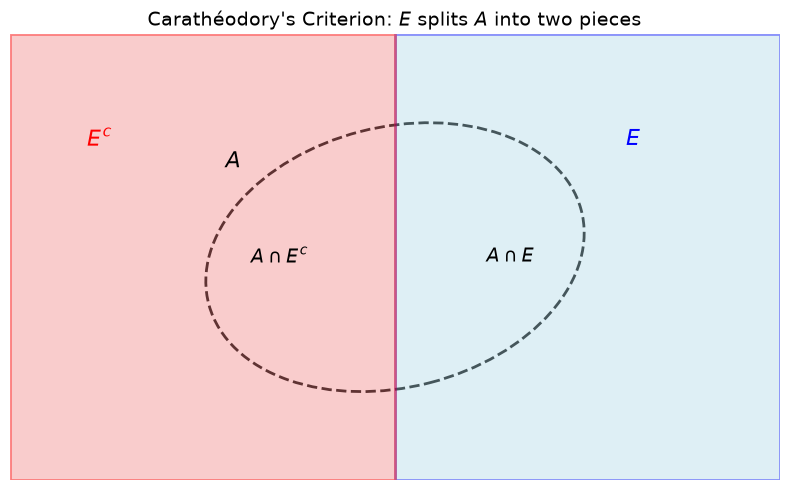

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle

fig, ax = plt.subplots(figsize=(8, 5))

# Draw set A
ellipse = Ellipse((4, 3), width=5, height=3.5, angle=15, 
                  facecolor='none', edgecolor='black', lw=2, linestyle='--')
ax.add_patch(ellipse)
ax.text(1.8, 4.2, '$A$', fontsize=16, fontweight='bold')

# Draw set E (right side of the dividing line)
rect_E = Rectangle((4, 0), 5, 6, facecolor='lightblue', alpha=0.4, edgecolor='blue', lw=2)
ax.add_patch(rect_E)
ax.text(7, 4.5, '$E$', fontsize=16, color='blue', fontweight='bold')

# Draw set E^c (left side)
rect_Ec = Rectangle((-1, 0), 5, 6, facecolor='lightcoral', alpha=0.4, edgecolor='red', lw=2)
ax.add_patch(rect_Ec)
ax.text(0, 4.5, '$E^c$', fontsize=16, color='red', fontweight='bold')

# Text for intersections
ax.text(2.5, 3, '$A \cap E^c$', fontsize=14, ha='center', va='center')
ax.text(5.5, 3, '$A \cap E$', fontsize=14, ha='center', va='center')

# Formatting
ax.set_xlim(-1, 9)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title("Carathéodory's Criterion: $E$ splits $A$ into two pieces", fontsize=14)

plt.tight_layout()
plt.show()


## 2. A Crucial Simplification

When proving that a set $E$ is measurable, checking the exact equality $m^*(A) = m^*(A \cap E) + m^*(A \cap E^c)$ for every subset $A \subseteq \mathbb{R}$ can be tedious. However, we can simplify this requirement significantly.

By the [subadditivity](lebesgue-outer-measure.ipynb#further-properties-translation-invariance-and-subadditivity) of the outer measure, for any sets $X$ and $Y$, we always have $m^*(X \cup Y) \le m^*(X) + m^*(Y)$.
Since $A = (A \cap E) \cup (A \cap E^c)$, it is inherently true for *any* set $E$ and any set $A$ that:

$$m^*(A) \le m^*(A \cap E) + m^*(A \cap E^c)$$

::: {.callout-warning}

## Sufficient Condition for Measurability

Because the "less than or equal to" bound comes for free from subadditivity, we only ever need to prove the reverse inequality.

To prove $E$ is measurable, it is sufficient to show that for any test set $A$:

$$m^*(A) \ge m^*(A \cap E) + m^*(A \cap E^c)$$

:::

## 3. Example: An Infinite Ray is Measurable

Let's prove a concrete example using the simplification derived above.

**Proposition:** The set $E = [0, \infty)$ is measurable in $\mathbb{R}$.

::: {.callout-tip collapse="true"}

## Proof of Proposition

Let $A \subseteq \mathbb{R}$ be an arbitrary test set. We must show that:

$$m^*(A) \ge m^*(A \cap E) + m^*(A \cap E^c)$$

**Step 1: Setting up an open cover**
By the definition of outer measure, for any $\epsilon > 0$, there exists a countable cover of $A$ by open intervals $\{I_k\}$ such that:

$$m^*(A) + \epsilon \ge \sum_{k=1}^\infty |I_k|$$

**Step 2: Splitting the cover**
For each interval $I_k$, the set $E = [0, \infty)$ naturally splits it into two pieces:

$$I_k' = I_k \cap E \quad \text{and} \quad I_k'' = I_k \cap E^c$$

Since $I_k$ is an interval and $E$ is an interval, $I_k'$ and $I_k''$ are also intervals (though possibly half-open or closed), and importantly, their lengths satisfy:

$$|I_k| = |I_k'| + |I_k''|$$

Because $\{I_k\}$ covers $A$, we know that:

1. $A \cap E \subseteq \bigcup_{k=1}^\infty I_k'$
2. $A \cap E^c \subseteq \bigcup_{k=1}^\infty I_k''$

**Step 3: Handling the topology of the intervals (The $\epsilon$-trick)**
The pieces $I_k'$ and $I_k''$ cover $A \cap E$ and $A \cap E^c$, respectively. However, they might not be *open* intervals, which strictly limits us from immediately bounding the outer measures (outer measure is typically defined via infimums of *open* intervals).

To resolve this, we slightly expand each $I_k'$ and $I_k''$ into an open interval. By adding a tiny margin to the endpoints, we can find open intervals $J_k'$ and $J_k''$ such that:
$I_k' \subseteq J_k'$ with $|J_k'| \le |I_k'| + \frac{\epsilon}{2^{k+1}}$
$I_k'' \subseteq J_k''$ with $|J_k''| \le |I_k''| + \frac{\epsilon}{2^{k+1}}$

Now, $\{J_k'\}$ is a valid open cover for $A \cap E$, and $\{J_k''\}$ is a valid open cover for $A \cap E^c$. Therefore:

$$\begin{aligned}
m^*(A \cap E) &\le \sum_{k=1}^\infty |J_k'| \le \sum_{k=1}^\infty |I_k'| + \frac{\epsilon}{2} \\
m^*(A \cap E^c) &\le \sum_{k=1}^\infty |J_k''| \le \sum_{k=1}^\infty |I_k''| + \frac{\epsilon}{2}
\end{aligned}$$

**Step 4: Synthesis**
Summing these two inequalities gives:

$$\begin{aligned}
m^*(A \cap E) + m^*(A \cap E^c) &\le \sum_{k=1}^\infty |I_k'| + \sum_{k=1}^\infty |I_k''| + \epsilon \\
&= \sum_{k=1}^\infty (|I_k'| + |I_k''|) + \epsilon \\
&= \sum_{k=1}^\infty |I_k| + \epsilon \\
&\le (m^*(A) + \epsilon) + \epsilon = m^*(A) + 2\epsilon
\end{aligned}$$

Since $\epsilon > 0$ was arbitrary, we can let $\epsilon \to 0$, which yields:

$$m^*(A \cap E) + m^*(A \cap E^c) \le m^*(A)$$

This establishes the required inequality, proving that $E = [0, \infty)$ is Lebesgue measurable. $\blacksquare$
:::